In [1]:
import BioSimSpace as BSS
import sire as sr

INFO:rdkit:Enabling RDKit 2025.03.6 jupyter extensions
INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
wt = BSS.IO.readMolecules("inputs/1choFH_apo_wt_flare_processed.pdb")
mut = BSS.IO.readMolecules("inputs/1choFH_apo_mut_flare_processed.pdb")

In [3]:
wt = BSS.Parameters.ff14SB(wt[0], ensure_compatible=False).getMolecule()
mut = BSS.Parameters.ff14SB(mut[0], ensure_compatible=False).getMolecule()

Comparing the residues between two proteins shows us that the residues
at index 15 are different between the proteins

In [4]:
roi = []
for i, res in enumerate(wt.getResidues()):
    if res.name() != mut.getResidues()[i].name():
        print(res, mut.getResidues()[i])
        roi.append(res.index())

<BioSimSpace.Residue: name='LEU', molecule=4, index=15, nAtoms=19> <BioSimSpace.Residue: name='PRO', molecule=6, index=15, nAtoms=14>


We can then provide a custom ROI mapping to create a ring-breaking transformation

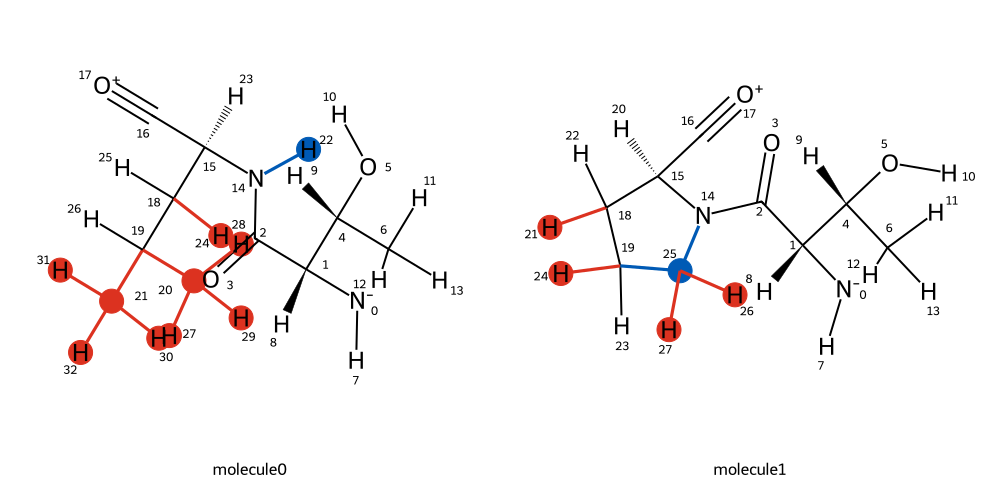

In [5]:
mapping = BSS.Align.matchAtoms(molecule0=wt, molecule1=mut, roi=[15], custom_roi_map={204:204,205:205,203:203,202:202,211:208,206:206,213:210,207:207,214:211,210:213})

BSS.Align.viewMapping(wt, mut, mapping, roi=15, pixels=500)

We use the `allow_ring_breaking=True` to tell BioSimSpace to setup a transformation involving bond alchemy

In [6]:
aligned_wt = BSS.Align.rmsdAlign(molecule0=wt, mapping=mapping, molecule1=mut)
merged_protein = BSS.Align.merge(aligned_wt, mut, mapping, allow_ring_breaking=True, roi=[15])

We can convert the BioSimSpace system to Sire to check what parameters are changing

In [7]:
merged_protein_sire = sr.convert.biosimspace_to_sire(merged_protein)
merged_protein = merged_protein.toSystem()

In [8]:
mol = merged_protein_sire
pert = mol.perturbation()
pert_omm = pert.to_openmm(map={"coordinates":"coordinates0"})

We can see that the alchemical transformation will now involve a creation of a bond:

In [9]:
pert_omm.changed_bonds()

,bond,length0,length1,k0,k1
0,N:203-H:211,0.1010,0.1449,363171.2,282001.6
1,CG:208-H:211,0.1526,0.1526,0.0,259408.0


We can continue with setting up and exporting our protein system 

In [10]:
# Solvate the merged system
# Initialize base shape to extract the correct angles for a truncated octahedron
_, angles = BSS.Box.truncatedOctahedron(10 * BSS.Units.Length.nanometer)

# Calculate bounding box
box_min, box_max = merged_protein.getAxisAlignedBoundingBox()
box_size = [y - x for x, y in zip(box_min, box_max)]

# Apply padding
padding = 1.5 * BSS.Units.Length.nanometer
box_length = max(box_size) + 2 * padding

# Solvate
solvated = BSS.Solvent.tip3p(
    molecule=merged_protein,
    box=3 * [box_length],
    angles=angles,
    ion_conc=0.15,
    is_neutral=True, # IMPORTANT: This will add ions to neutralize the system
)
solvated.reduceBoxVectors()

In [11]:
# Save the perturbable protein and ligand system
BSS.Stream.save(solvated, "../02_simulation/OMTKY3-L18P")